# Chapter 10 — A Revolver, Not a Foundation

**Companion to *Applied AI*.**

This notebook accompanies Chapter 10. The chapter argues that a model is an
*occupant* of a named chamber, not a foundation, and that a release is a
per-chamber experiment rather than a global upgrade.

This notebook does not invent model comparison data. It uses the book's own
frozen **P1.1** run: three real models, 40 real repair tasks, 280 real calls,
each candidate scored by a hidden verifier.

## Question

**Can one model win a chamber and lose another — and what would a global
"upgrade to the new model" decision have thrown away?**

## What this notebook establishes

- Per-occupant pass rates recomputed from the frozen export: the three models
  differ sharply, reproducing the chapter's 30/40, 19/40 and 15/40.
- A per-task matrix showing that the weakest occupant solves tasks the
  strongest one fails — so the ranking is **not** a total order.
- **Negative flips** counted for every pair: tasks an incumbent passes that a
  candidate fails. This is the number a single aggregate score hides.
- Cost per passing item, using tokens as the available price proxy.

## What this notebook does **not** establish

- This is **one frozen run** on one synthetic 40-task corpus with three small
  local models, one draw per model per task. It supports no claim about these
  models in general, and none about any other model.
- The P-series arms were not designed as a chamber-swap experiment. Reading
  them as three chamber occupants is **this notebook's framing**, and the
  chapter's release protocol was never run as a single mechanism.
- Local models carry no monetary price, so "cost" here is **tokens**, not
  money. The chapter's utility row asks for cost per passing item in money.
- One draw per model per task means per-task differences carry **no**
  significance. Chapters 25 and 27 show what happens when they are tested.

## Setup

In [1]:
import json
import os
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt

def find_evidence_dir(marker="p-series"):
    """Locate the preserved evidence. Override with APPLIED_AI_EVIDENCE."""
    env = os.environ.get("APPLIED_AI_EVIDENCE")
    if env and Path(env).expanduser().is_dir():
        return Path(env).expanduser()
    here = Path.cwd().resolve()
    for base in (here, *here.parents):
        for cand in (base / "evidence",
                     base / "experiments" / "applied-ai" / "evidence"):
            if (cand / marker).is_dir():
                return cand
    raise FileNotFoundError(
        "Preserved evidence not found. Set APPLIED_AI_EVIDENCE to the "
        "directory holding the Applied AI evidence bundles."
    )

EVIDENCE_DIR = find_evidence_dir()
EXPORT = EVIDENCE_DIR / "p-series" / "p11" / "p11-export.json"
print("EVIDENCE_DIR:", EVIDENCE_DIR)

data = json.loads(EXPORT.read_text(encoding="utf-8"))
print("format        :", data["format"])
print("corpus        :", data["experiment"]["corpus_version"])
print("calls         :", len(data["calls"]))
print("candidates    :", len(data["candidates"]))
print("arms          :", sorted({c["arm"] for c in data["candidates"]}))

EVIDENCE_DIR: $APPLIED_AI_EVIDENCE
format        : codeai-experiment-export-v1
corpus        : semantic-repair-v1
calls         : 280
candidates    : 280
arms          : ['C0', 'C1', 'H1']


## Reading the export

Candidates carry the outcome; calls carry the model. Join them on `call_id`.
The **H1** arm is the one that sent one draw to each of three different models,
so it is the arm that can be read as three chamber occupants.

In [2]:
model_of = {c["call_id"]: c.get("model") for c in data["calls"]}
tokens_of = {c["call_id"]: (c.get("input_tokens") or 0) + (c.get("output_tokens") or 0)
             for c in data["calls"]}
latency_of = {c["call_id"]: c.get("latency_ms") for c in data["calls"]}

h1 = [c for c in data["candidates"] if c["arm"] == "H1"]
tasks = sorted({c["corpus_task_id"] for c in h1})
occupants = sorted({model_of[c["call_id"]] for c in h1})

print(f"tasks in corpus : {len(tasks)}")
print(f"occupants       : {occupants}")
print(f"outcomes seen   : {sorted({c['outcome'] for c in h1})}")

tasks in corpus : 40
occupants       : ['llama3.1:8b', 'mistral:7b-instruct', 'qwen2.5-coder:latest']
outcomes seen   : ['EXECUTION_ERROR', 'VERIFIER_FAIL', 'VERIFIER_PASS']


## 1. The chamber scoreboard

In [3]:
def passed(c):
    return c["outcome"] == "VERIFIER_PASS"

rows = {}
for m in occupants:
    mine = [c for c in h1 if model_of[c["call_id"]] == m]
    rows[m] = {
        "n": len(mine),
        "pass": sum(passed(c) for c in mine),
        "exec_err": sum(c["outcome"] == "EXECUTION_ERROR" for c in mine),
        "tokens": sum(tokens_of[c["call_id"]] for c in mine),
        "p50_ms": sorted(latency_of[c["call_id"]] for c in mine)[len(mine)//2],
    }

print(f"{'occupant':<26}{'passes':<10}{'rate':<9}{'exec err':<10}"
      f"{'tokens':<10}{'tokens/pass':<13}{'p50 ms'}")
print("-" * 92)
for m, r in sorted(rows.items(), key=lambda kv: -kv[1]["pass"]):
    tpp = r["tokens"] / r["pass"] if r["pass"] else float("nan")
    print(f"{m:<26}{r['pass']}/{r['n']:<7}{r['pass']/r['n']:<9.3f}"
          f"{r['exec_err']:<10}{r['tokens']:<10,}{tpp:<13,.0f}{r['p50_ms']}")

assert rows["qwen2.5-coder:latest"]["pass"] == 30
assert rows["llama3.1:8b"]["pass"] == 19
assert rows["mistral:7b-instruct"]["pass"] == 15
print()
print("assertion held: reproduces the chapter's 30/40, 19/40, 15/40")

occupant                  passes    rate     exec err  tokens    tokens/pass  p50 ms
--------------------------------------------------------------------------------------------
qwen2.5-coder:latest      30/40     0.750    0         7,559     252          6945
llama3.1:8b               19/40     0.475    0         8,686     457          7298
mistral:7b-instruct       15/40     0.375    3         13,239    883          8973

assertion held: reproduces the chapter's 30/40, 19/40, 15/40


## Observation

The ranking is unambiguous *in aggregate*. If a chamber's only question were
"which occupant passes most often", this table answers it and the chapter would
be unnecessary.

## 2. The ranking is not a total order

Now the per-task view. A single aggregate hides whether the weaker occupants
ever succeed where the strongest fails.

In [4]:
grid = {m: {} for m in occupants}
for c in h1:
    grid[model_of[c["call_id"]]][c["corpus_task_id"]] = passed(c)

best = "qwen2.5-coder:latest"
others = [m for m in occupants if m != best]

interesting = [t for t in tasks
               if not grid[best][t] and any(grid[m][t] for m in others)]

print(f"tasks the strongest occupant FAILED but another solved: {len(interesting)}")
print()
hdr = f"{'task':<30}" + "".join(f"{m.split(':')[0][:12]:<14}" for m in occupants)
print(hdr)
print("-" * len(hdr))
for t in interesting:
    line = f"{t:<30}"
    for m in occupants:
        line += f"{'PASS' if grid[m][t] else 'fail':<14}"
    print(line)

tasks the strongest occupant FAILED but another solved: 3

task                          llama3.1      mistral       qwen2.5-code  
------------------------------------------------------------------------
v2-price-freshness            fail          PASS          fail          
v2-retry-delivery             PASS          fail          fail          
v2-strip-query                fail          PASS          fail          


Those rows are the chapter's point in miniature. Retiring the two weaker
occupants on the strength of the scoreboard would have given up every task in
that list.

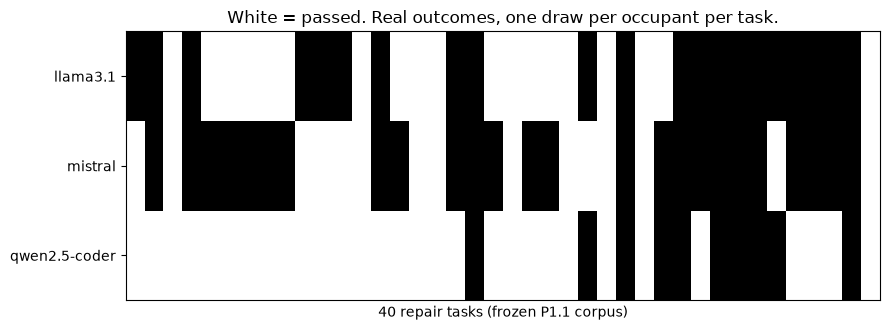

In [5]:
fig, ax = plt.subplots(figsize=(9, 3.4))
import numpy as np
mat = np.array([[1 if grid[m][t] else 0 for t in tasks] for m in occupants])
ax.imshow(mat, aspect="auto", cmap="Greys_r", vmin=0, vmax=1)
ax.set_yticks(range(len(occupants)))
ax.set_yticklabels([m.split(":")[0] for m in occupants])
ax.set_xticks([])
ax.set_xlabel(f"{len(tasks)} repair tasks (frozen P1.1 corpus)")
ax.set_title("White = passed. Real outcomes, one draw per occupant per task.")
plt.tight_layout()
plt.show()

## 3. Negative flips: what a global upgrade would cost

The chapter's rule: *a higher average with flips on items you depend on is not
a win for that chamber.* Count them in both directions for every pair.

In [6]:
def flips(incumbent, candidate):
    lost = [t for t in tasks if grid[incumbent][t] and not grid[candidate][t]]
    won  = [t for t in tasks if not grid[incumbent][t] and grid[candidate][t]]
    return lost, won

print(f"{'incumbent -> candidate':<52}{'net':<8}{'NEGATIVE FLIPS':<18}{'gained'}")
print("-" * 96)
for inc in occupants:
    for cand in occupants:
        if inc == cand:
            continue
        lost, won = flips(inc, cand)
        net = len(won) - len(lost)
        label = f"{inc.split(':')[0]} -> {cand.split(':')[0]}"
        print(f"{label:<52}{net:<+8}{len(lost):<18}{len(won)}")

incumbent -> candidate                              net     NEGATIVE FLIPS    gained
------------------------------------------------------------------------------------------------
llama3.1 -> mistral                                 -4      10                6
llama3.1 -> qwen2.5-coder                           +11     1                 12
mistral -> llama3.1                                 +4      6                 10
mistral -> qwen2.5-coder                            +15     2                 17
qwen2.5-coder -> llama3.1                           -11     12                1
qwen2.5-coder -> mistral                            -15     17                2


In [7]:
lost, won = flips("llama3.1:8b", "qwen2.5-coder:latest")
print("Swapping llama -> qwen, the strongest occupant overall:")
print(f"  net gain        : {len(won) - len(lost):+d} tasks")
print(f"  tasks GAINED    : {len(won)}")
print(f"  tasks LOST      : {len(lost)}   <-- negative flips")
for t in lost:
    print("      -", t)
print()
print("A swap that improves the average still gives something up. Whether that")
print("matters is a question about the chamber's work, not about the average.")

Swapping llama -> qwen, the strongest occupant overall:
  net gain        : +11 tasks
  tasks GAINED    : 12
  tasks LOST      : 1   <-- negative flips
      - v2-retry-delivery

A swap that improves the average still gives something up. Whether that
matters is a question about the chamber's work, not about the average.


## 4. What the chapter asks per chamber

The chapter's six properties. Three of them are answerable from this export;
three are not, and saying so is part of the exercise.

In [8]:
answerable = {
    "Speed":     "yes - p50 latency per occupant, above",
    "Quality":   "yes - pass rate against the hidden verifier, above",
    "Gain":      "yes - paired per-task flips, above",
    "Knowledge": "NO - the corpus has no domain or recency probes",
    "Applicability": "NO - context length, modality and structured output untested",
    "Utility":   "PARTIAL - tokens per passing item only; local models have no price",
}
for k, v in answerable.items():
    print(f"  {k:<16}{v}")

  Speed           yes - p50 latency per occupant, above
  Quality         yes - pass rate against the hidden verifier, above
  Gain            yes - paired per-task flips, above
  Knowledge       NO - the corpus has no domain or recency probes
  Applicability   NO - context length, modality and structured output untested
  Utility         PARTIAL - tokens per passing item only; local models have no price


## Interpretation

The chapter's architecture is what makes this table possible at all. Because a
chamber is a **name** bound to an occupant, the same 40 tasks can be replayed
against three different models and compared per item. Nothing in the process
had to change to ask the question.

Three readings, in the chapter's own bounds:

- **Occupants differ sharply**, and on this corpus the ordering is stable in
  aggregate.
- **The ordering is not a total order.** Weaker occupants solve tasks the
  strongest fails. A global upgrade discards that information; a per-chamber
  decision keeps it.
- **Every swap has negative flips.** The chapter's release protocol asks you to
  count them and decide whether they matter *for that chamber's work* — not to
  compare two summary scores.

And the limit the chapter insists on: with one draw per model per task, a
handful of flips can be chance. *"If only four items differ and three favour
the candidate, a fair coin produces a split at least that lopsided more often
than not."* Chapter 25 runs exactly that test on this corpus.

## Try it yourself

1. **Treat each task family as a separate chamber.** Group the task ids by
   prefix and recompute the ranking per group. Does the same occupant win every
   chamber?
2. **Price the utility row.** Invent a per-token price for each occupant and
   recompute cost per *passing* item rather than per call. Which occupant wins
   at a 10x price difference, and at 100x?
3. **Run the chapter's release protocol** on one pair: replay the frozen set,
   compare paired per item, count flips both ways, and write the decision down
   with both occupant versions. It is a day of work per release, and this is
   the data for it.
4. **Load `p1-export.json` instead** and repeat. On that easier corpus every
   arm covers the same 11 of 12 tasks — there is nothing to choose between
   occupants at all. That is Chapter 24's ceiling.